In [1]:
import pandas as pd

# Load CSV File
df = pd.read_csv('breast-cancer.csv')

# check first 5 rows
print(df.head())

# check Columns and data types 
print(df.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

if df['diagnosis'].dtype == 'object':
    le = LabelEncoder()
    df['diagnosis'] = le.fit_transform(df['diagnosis'])


X = df.drop(['diagnosis', 'id'], axis=1, errors='ignore') 
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preprocessing complete!")

Data preprocessing complete!


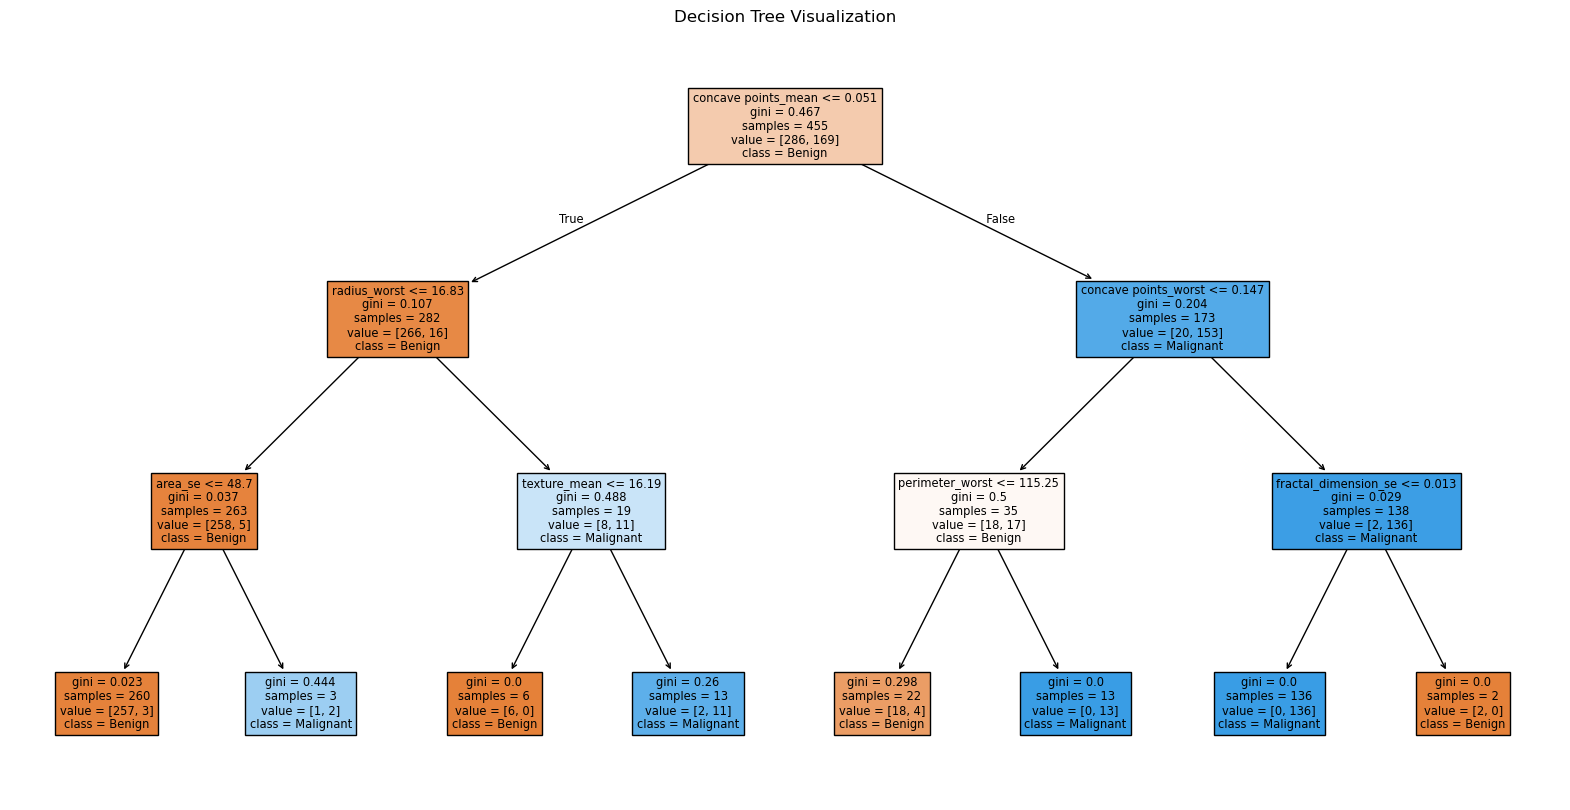

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Model initialize abs train
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(X_train, y_train)

# Tree visualize
plt.figure(figsize=(20,10))
plot_tree(dt_clf, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predictions
dt_pred = dt_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)

print("--- Decision Tree Performance ---")
print(classification_report(y_test, dt_pred))

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, rf_pred))

--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        71
           1       0.95      0.91      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



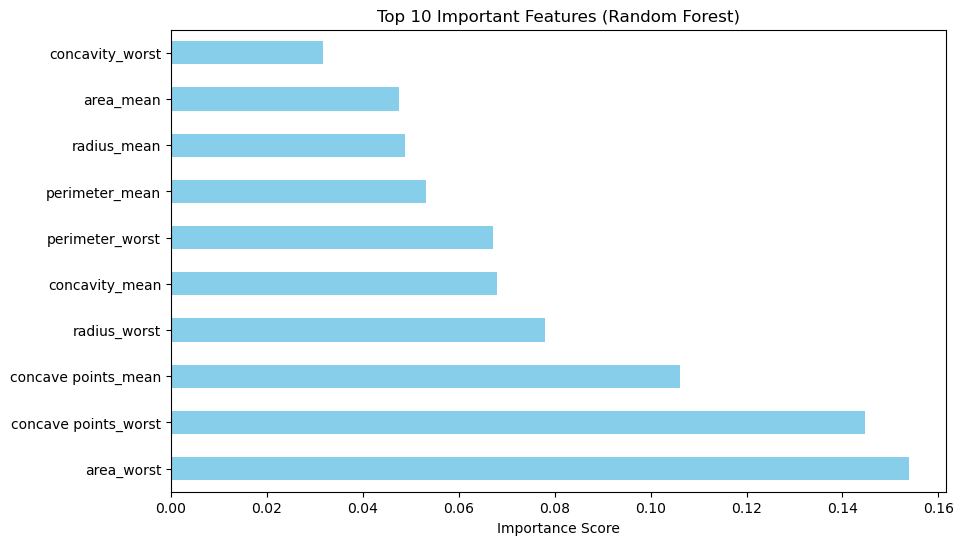

In [5]:
import seaborn as sns

# Feature importance
importances = rf_clf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)

# Top 10 features plot
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.show()